<a href="https://colab.research.google.com/github/han2109/Credit-Scoring/blob/main/_nh_gi_t_n_d_ng_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Upload CSV file from local system
from google.colab import files
uploaded = files.upload()

Saving Data_For Midterm and Final Project.xlsx to Data_For Midterm and Final Project.xlsx


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
df_raw = pd.read_excel("Data_For Midterm and Final Project.xlsx")
df = df_raw.copy()
selected_columns = [
    'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME',
    'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY',
    'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT',"NHOMNOMOI"
]

# Lọc dataframe
df = df[selected_columns]

In [ ]:
pd.set_option('display.max_columns', None)   # Hiện tất cả các cột
pd.set_option('display.width', None)         # Không giới hạn độ rộng dòng
pd.set_option('display.max_colwidth', None)  # Hiện toàn bộ nội dung trong mỗi cột

# Xem dữ liệu
print(df.head())

        PHUONG THUC CHO VAY  LOAIKH  SEX CURRENCYCD      DESC_TIME  \
0            CV TG NGAY VND       1  ONG        VND   Vay ngan han   
1            CV TG NGAY VND       1  ONG        VND   Vay ngan han   
2            CV TG NGAY VND       1   MR        VND   Vay ngan han   
3  CV TL TH LAI DINH KY VND       1  NaN        VND  Vay trung han   
4            CV TG NGAY VND       1   MR        VND   Vay ngan han   

   MJACCTTYPDESC               ORGNAME       PARENTORGNAME  \
0  Vay Tieu dung    KLB - CN KHANH HOA  KLB - CN KHANH HOA   
1  Vay Tieu dung    KLB - PGD CAI LANG    KLB - CN DA NANG   
2  Vay Tieu dung      KLB - CN DA NANG    KLB - CN DA NANG   
3  Vay Tieu dung  KLB - PGD DIEN KHANH  KLB - CN KHANH HOA   
4  Vay Tieu dung      KLB - CN DA NANG    KLB - CN DA NANG   

                       MUCDICHVAY     BASE_BAL     CURR_BAL      DUNO_QD  \
0   1900-SX-DV Tu t.dung Gia dinh  787127020.0  851714900.0  851714900.0   
1      1811-CV mua Xe may tra gop  333388030.0  142450

In [ ]:
# Bước 2: Kiểm tra tổng số giá trị bị thiếu ở mỗi cột
print("🔎 Missing values per column:")
missing_per_column = df.isnull().sum()
print(missing_per_column[missing_per_column > 0])

# Bước 3: Kiểm tra và hiển thị các dòng bị thiếu
missing_rows = df[df.isnull().any(axis=1)]
num_missing_rows = missing_rows.shape[0]

print(f"\n📌 Total rows with missing values: {num_missing_rows}")

# Bước 4: Hiển thị bảng các dòng bị thiếu
if num_missing_rows > 0:
    print("\n📋 Rows with missing values:")
    print(missing_rows)
else:
    print("✅ No rows with missing values found.")

🔎 Missing values per column:
SEX    4330
dtype: int64

📌 Total rows with missing values: 4330

📋 Rows with missing values:
              PHUONG THUC CHO VAY  LOAIKH  SEX CURRENCYCD      DESC_TIME  \
3        CV TL TH LAI DINH KY VND       1  NaN        VND  Vay trung han   
136                    NQH NH VND       2  NaN        VND   Vay ngan han   
369                    NQH TH VND       2  NaN        VND  Vay trung han   
377                    NQH NH VND       1  NaN        VND   Vay ngan han   
452                CV TG NGAY VND       1  NaN        VND   Vay ngan han   
...                           ...     ...  ...        ...            ...   
90145    CV TL NH LAI DINH KY VND       1  NaN        VND   Vay ngan han   
90156    CV TL NH LAI DINH KY VND       1  NaN        VND   Vay ngan han   
90232    CV TL NH LAI DINH KY VND       1  NaN        VND   Vay ngan han   
90264  CV TL TH GOC, LAI D.KY VND       1  NaN        VND  Vay trung han   
90278    CV TL NH LAI DINH KY VND       1

In [ ]:
# Tính tỷ lệ thiếu dữ liệu của cột 'SEX'
missing_ratio_sex = df['SEX'].isnull().mean() * 100

print(f"Tỷ lệ thiếu của cột 'SEX': {missing_ratio_sex:.2f}%")

Tỷ lệ thiếu của cột 'SEX': 4.79%


In [ ]:
# Mapping giá trị SEX
sex_mapping = {
    'ONG': 'MR',
    'MR': 'MR',
    'BA': 'MRS',
    'MRS': 'MRS',
    'MS': 'MRS'
}

# Mapping giá trị SEX
sex_mapping = {
    'ONG': 'MR',
    'MR': 'MR',
    'BA': 'MRS',
    'MRS': 'MRS',
    'MS': 'MRS'
}

# Thay đổi giá trị theo mapping, giữ NaN
df['SEX'] = df['SEX'].map(sex_mapping).fillna('UNKNOWN')
# In ra các giá trị unique của cột 'SEX' sau khi xử lý
print(df['SEX'].unique())

['MR' 'UNKNOWN' 'MRS']


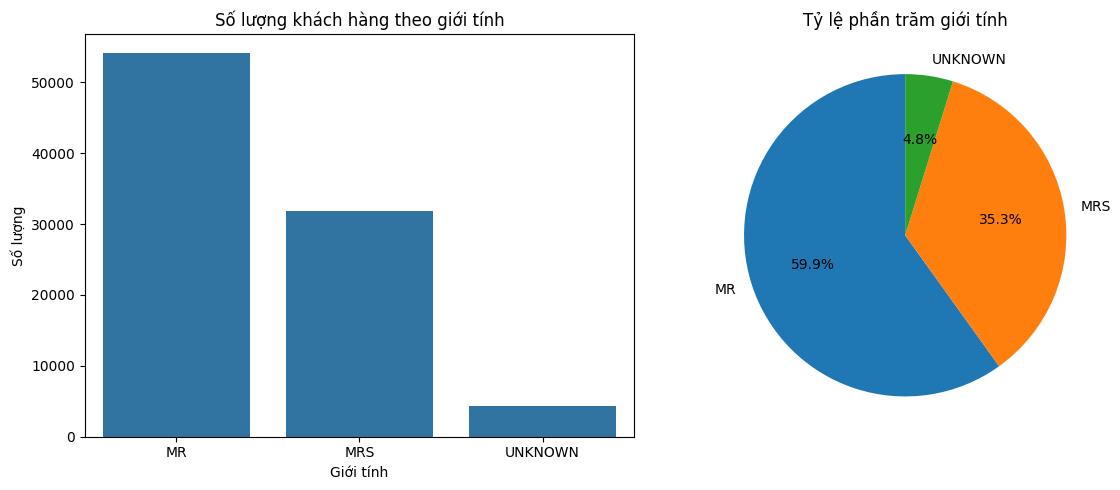

In [ ]:
# Tính tần suất và phần trăm
sex_counts = df['SEX'].value_counts()
sex_percent = sex_counts / sex_counts.sum() * 100

# Tạo biểu đồ 2 trong 1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🎯 Biểu đồ cột
sns.countplot(ax=axes[0], data=df, x='SEX', order=sex_counts.index)
axes[0].set_title('Số lượng khách hàng theo giới tính')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Số lượng')

# 🥧 Biểu đồ tròn
axes[1].pie(sex_percent, labels=sex_percent.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỷ lệ phần trăm giới tính')

plt.tight_layout()
plt.show()

In [ ]:
categorical_cols = [
    'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD',
    'DESC_TIME', 'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY'
]

# Khởi tạo danh sách kết quả
summary_data = []

# Duyệt qua từng cột và lưu từng giá trị + số lượng
for col in categorical_cols:
    value_counts = df[col].value_counts(dropna=False)
    for category, count in value_counts.items():
        summary_data.append({
            'Tên biến': col,
            'Giá trị category': category,
            'Số lượng': count
        })

# Tạo bảng kết quả
summary_df = pd.DataFrame(summary_data)

# Hiển thị bảng trong Colab
from IPython.display import display
display(summary_df)

,Tên biến,Giá trị category,Số lượng
0,PHUONG THUC CHO VAY,CV TL NH LAI DINH KY VND,42555
1,PHUONG THUC CHO VAY,CV THE TIN DUNG VISA_NGUNG SD,11662
2,PHUONG THUC CHO VAY,"CV TL TH GOC, LAI D.KY VND",10885
3,PHUONG THUC CHO VAY,CV THE JCB_NGUNG SD,7810
4,PHUONG THUC CHO VAY,"CV TL DH GOC, LAI D.KY VND",7312
...,...,...,...
309,MUCDICHVAY,0133-Tmua-CB-BQ-TT khac,1
310,MUCDICHVAY,0129-Khac,1
311,MUCDICHVAY,"0415-SX trang phuc, may mac",1
312,MUCDICHVAY,"0541-QL, XL rac thai, nuoc tha",1


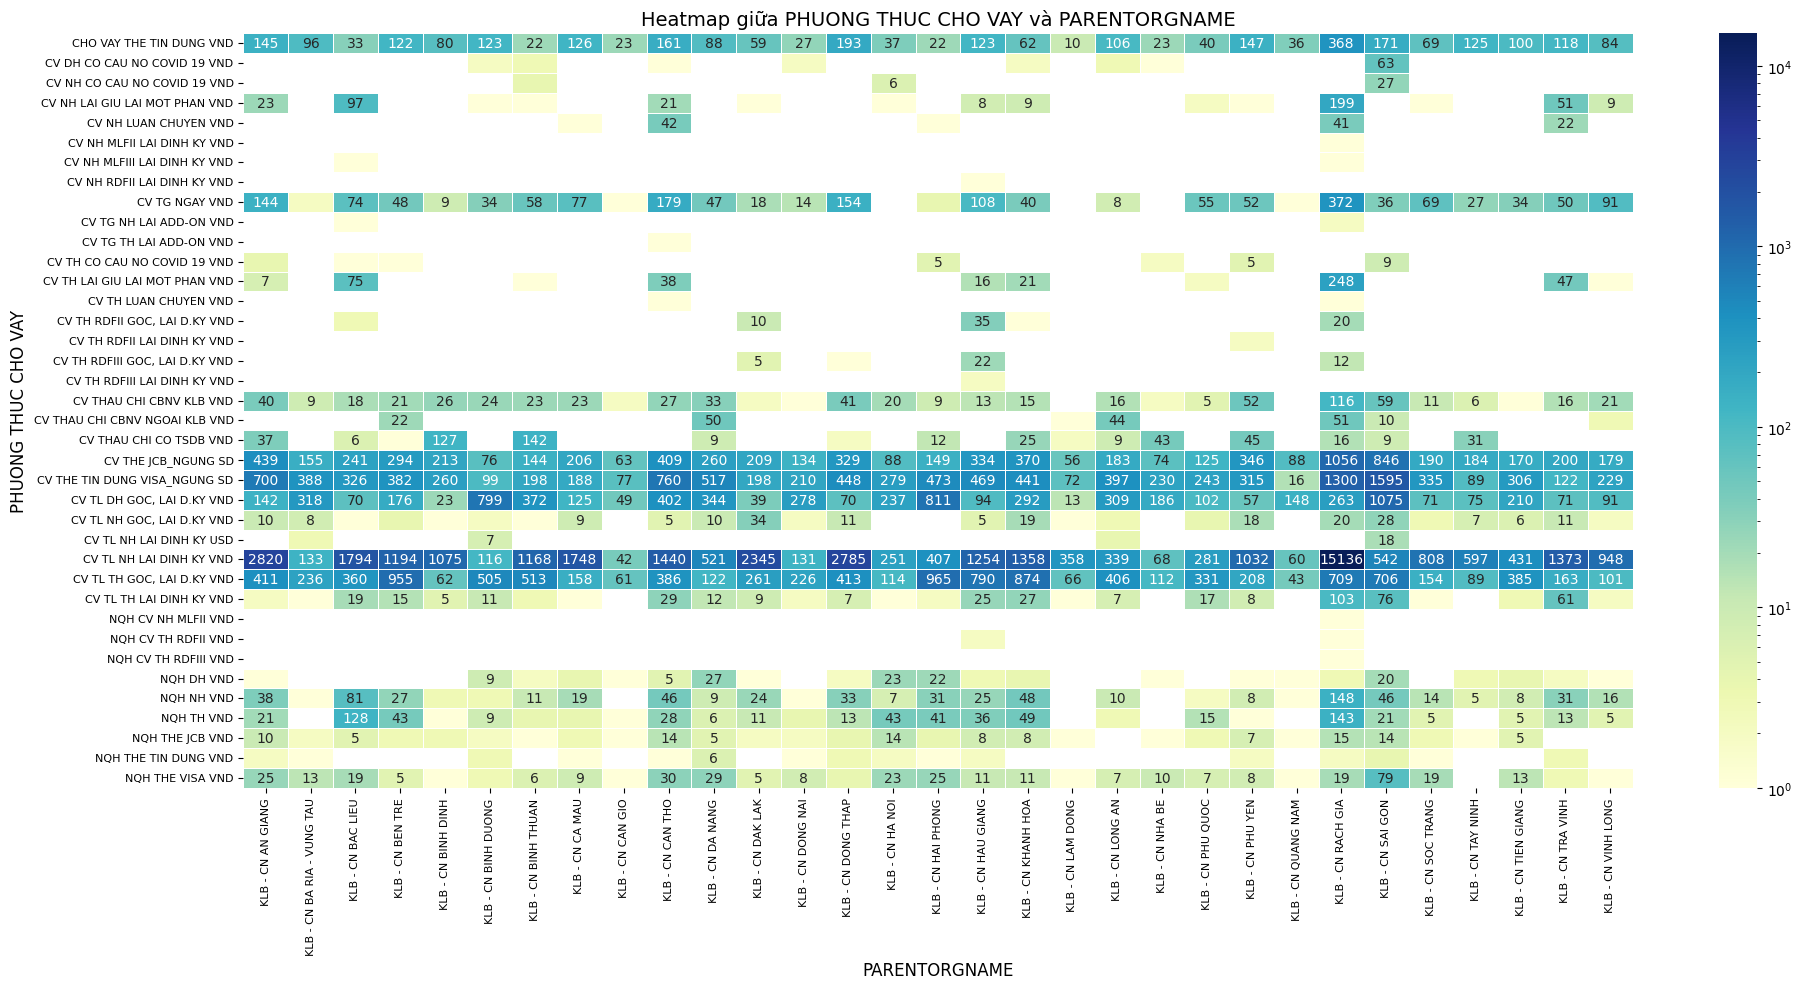

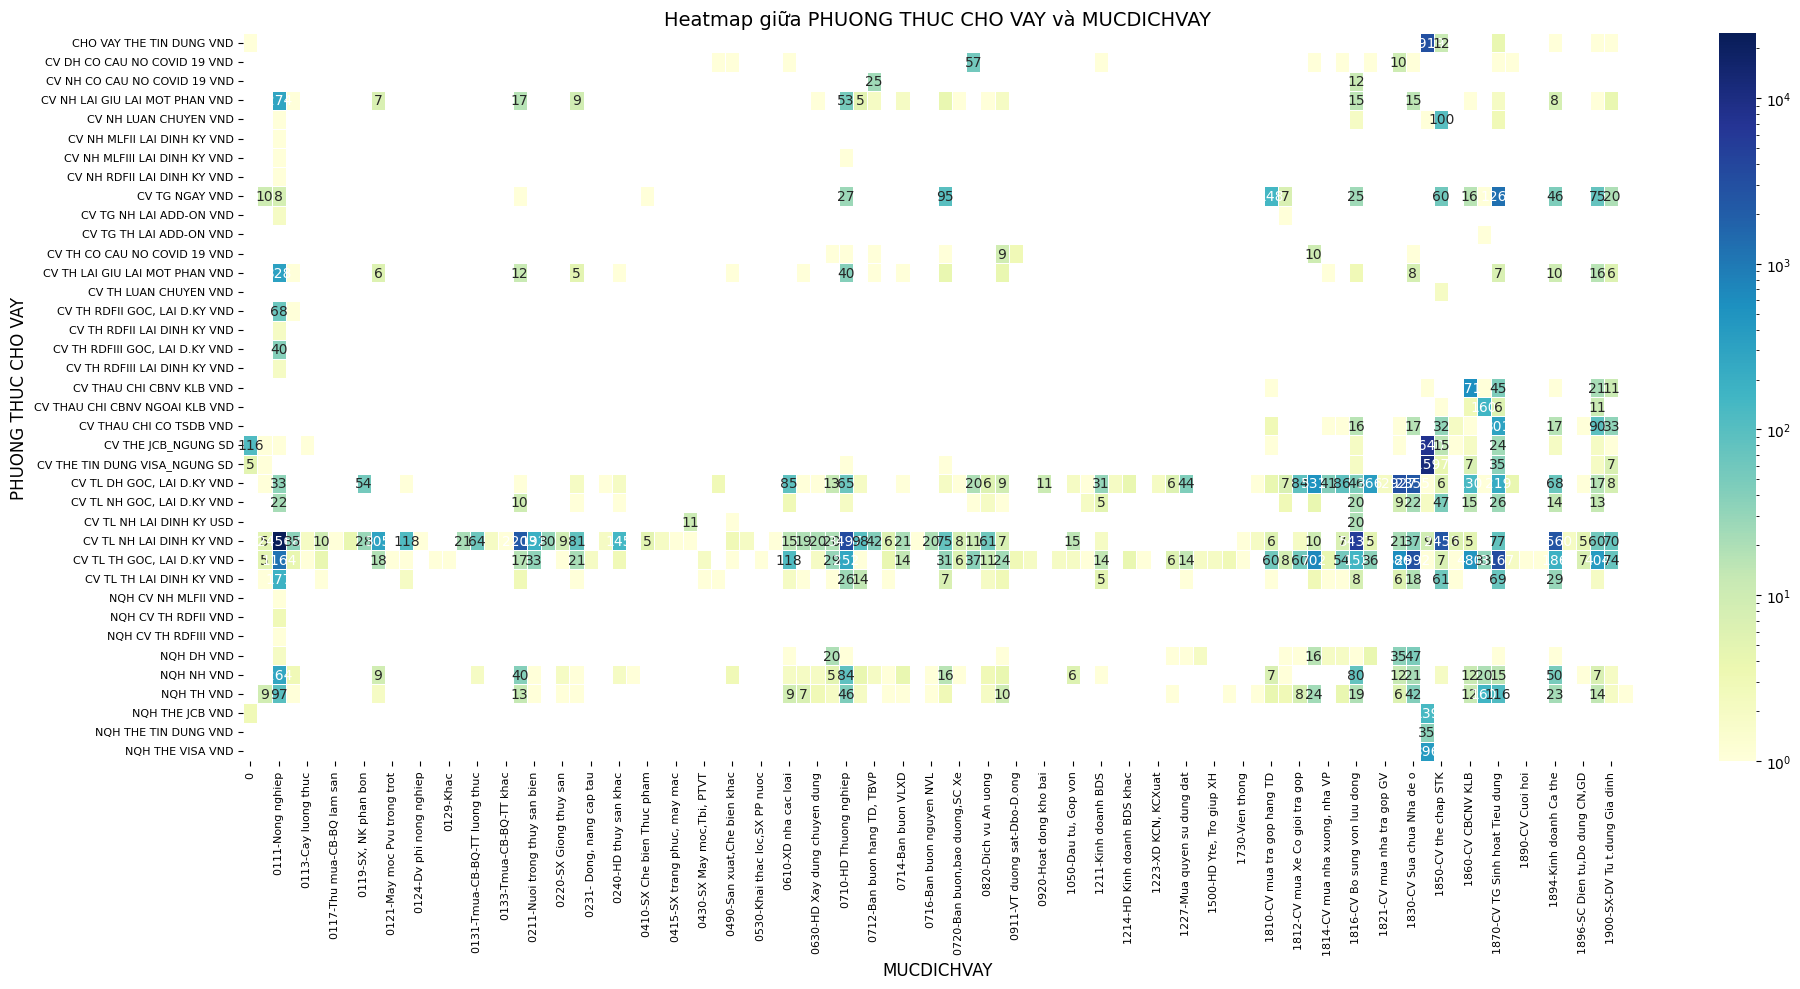

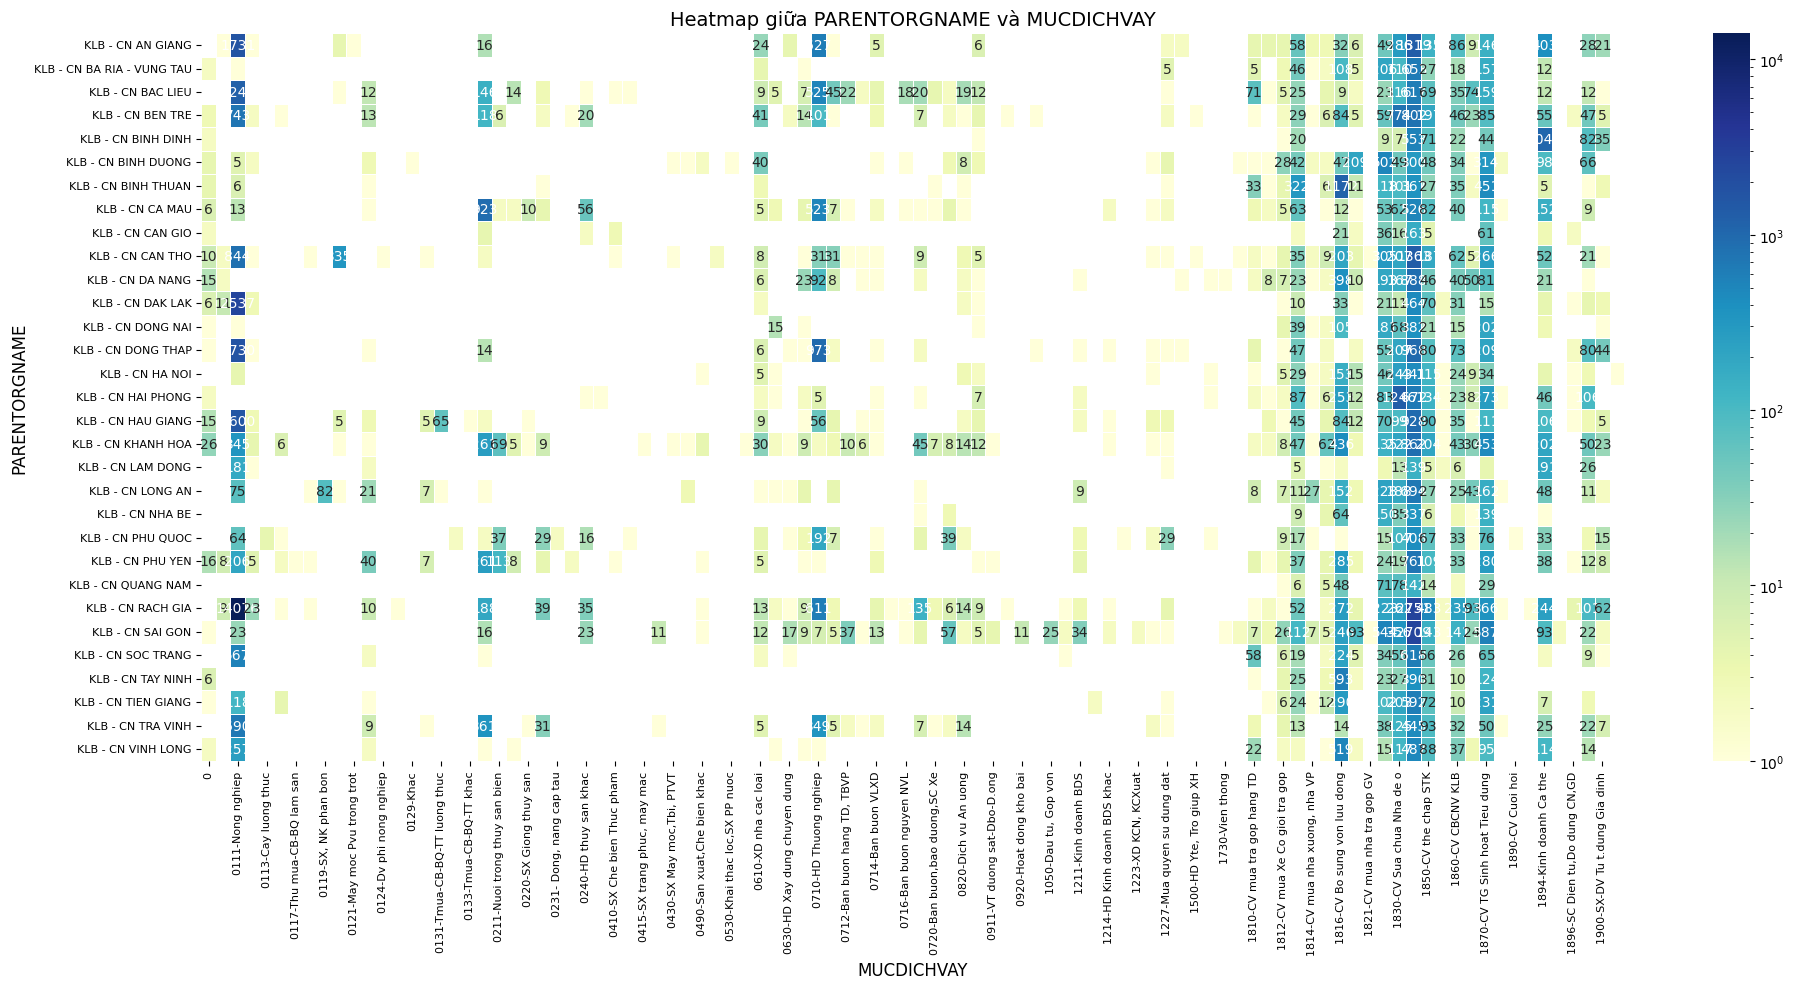

In [ ]:
from matplotlib.colors import LogNorm

cols = ['PHUONG THUC CHO VAY', 'PARENTORGNAME', 'MUCDICHVAY']

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        col1 = cols[i]
        col2 = cols[j]

        ct = pd.crosstab(df[col1], df[col2])

        # Ẩn các ô có giá trị nhỏ để không làm rối heatmap
        annot_data = ct.copy().astype(str)
        annot_data[ct < 5] = ""

        plt.figure(figsize=(20, 10))
        sns.heatmap(
            ct,
            cmap='YlGnBu',
            annot=annot_data,
            fmt='s',
            linewidths=0.5,
            norm=LogNorm()
        )
        plt.title(f"Heatmap giữa {col1} và {col2}", fontsize=14)
        plt.xlabel(col2, fontsize=12)
        plt.ylabel(col1, fontsize=12)
        plt.xticks(rotation=90, fontsize=8)
        plt.yticks(rotation=0, fontsize=8)
        plt.tight_layout()
        plt.show()

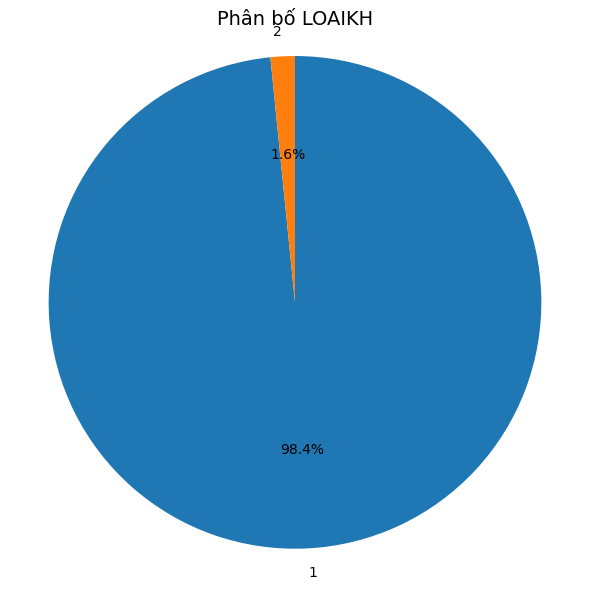

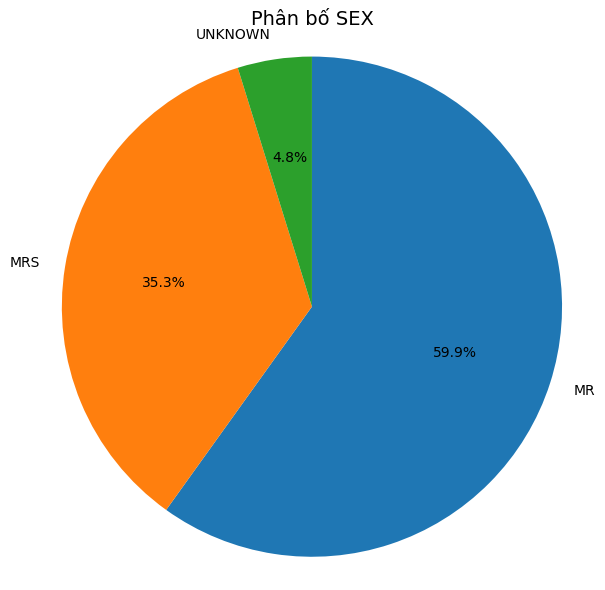

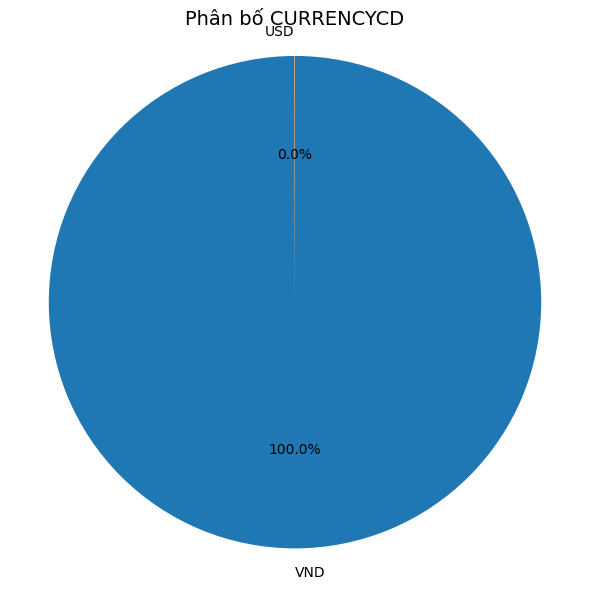

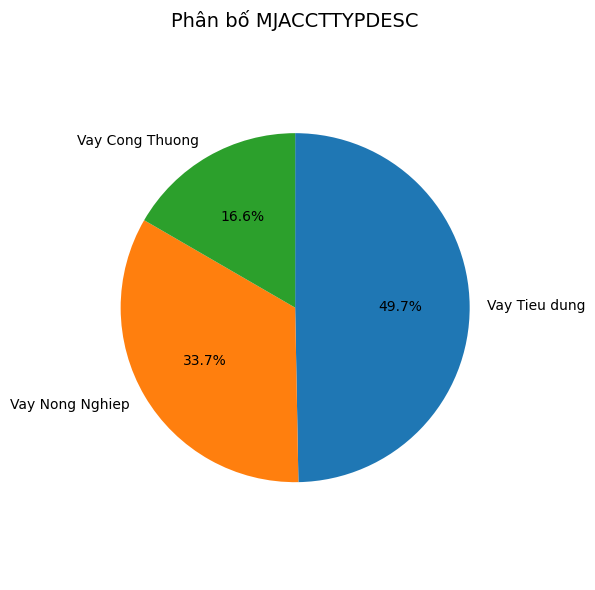

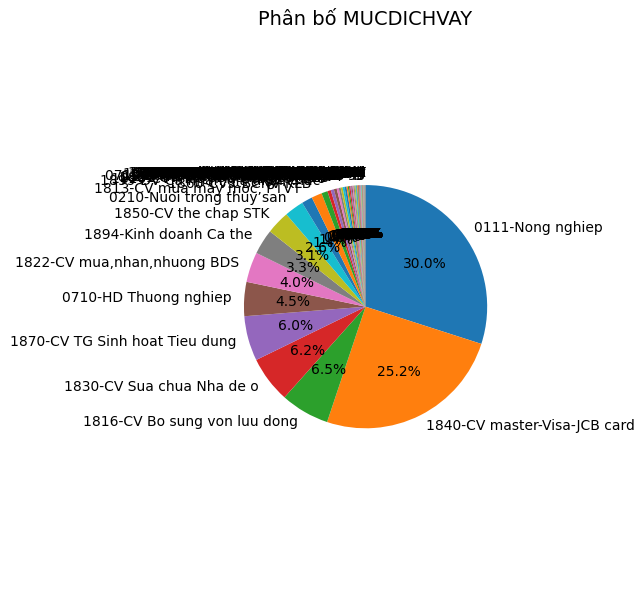

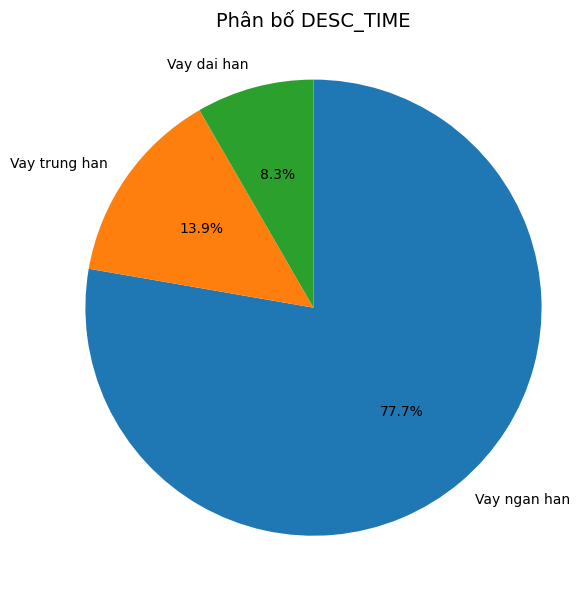

In [ ]:
# Danh sách các cột cần vẽ pie chart
cols = ['LOAIKH', 'SEX', 'CURRENCYCD', 'MJACCTTYPDESC', 'MUCDICHVAY', "DESC_TIME"]

for col in cols:
    counts = df[col].value_counts(dropna=False)

    # Tạo biểu đồ
    plt.figure(figsize=(6, 6))
    plt.pie(
        counts,
        labels=counts.index.astype(str),
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False
    )
    plt.title(f'Phân bố {col}', fontsize=14)
    plt.axis('equal')  # Đảm bảo hình tròn không bị méo
    plt.tight_layout()
    plt.show()

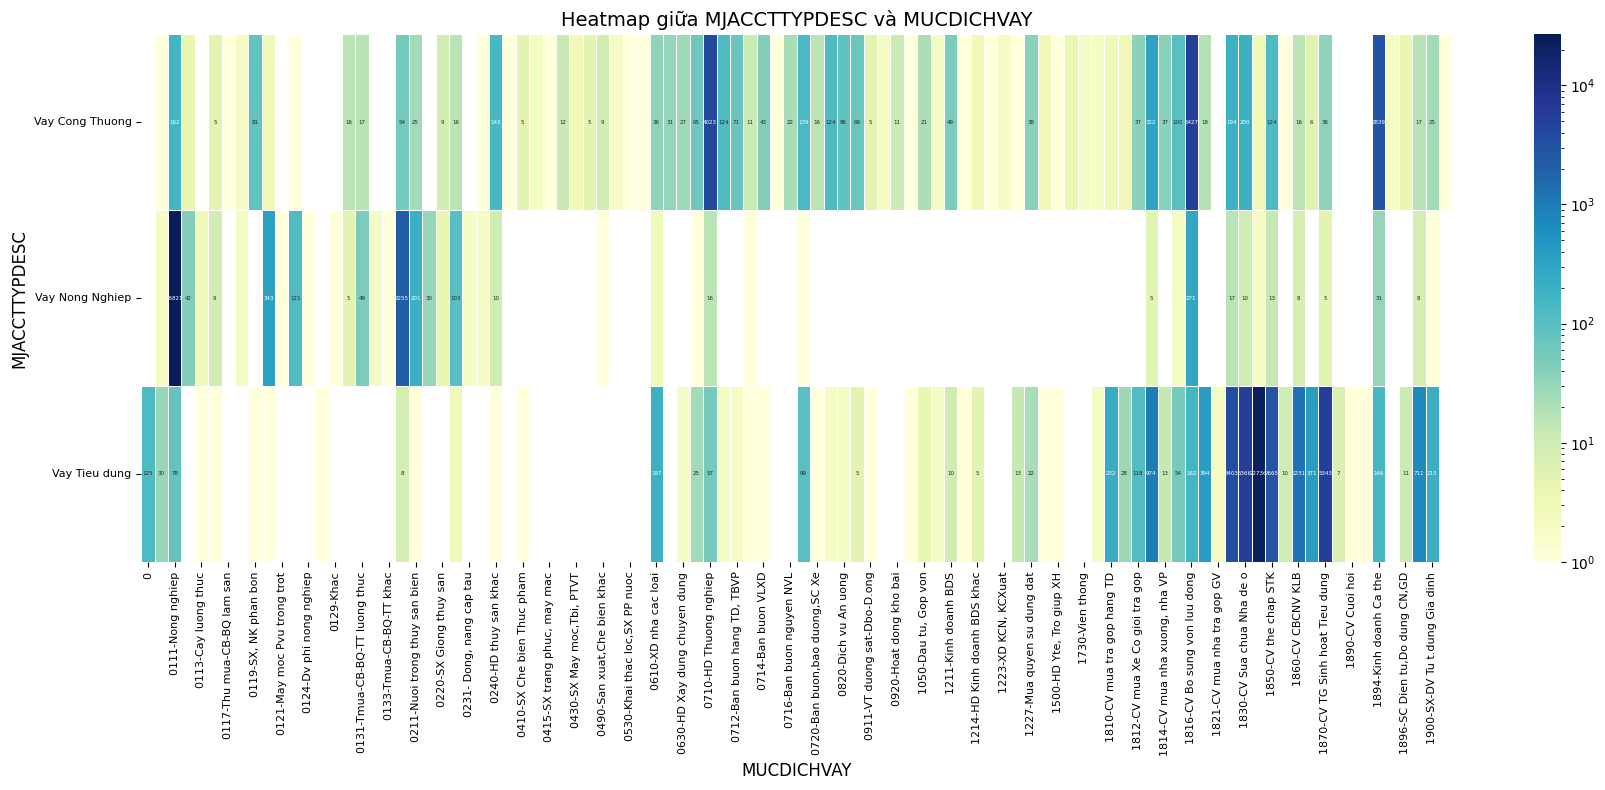

In [ ]:
# Tạo bảng chéo đếm số lượng giao dịch giữa 2 biến
ct = pd.crosstab(df['MJACCTTYPDESC'], df['MUCDICHVAY'])

# Tùy chọn: ẩn các ô quá nhỏ để không rối
annot_data = ct.copy().astype(str)
annot_data[ct < 5] = ""

# Vẽ heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(
    ct,
    cmap='YlGnBu',
    annot=annot_data,
    fmt='s',
    linewidths=0.7,
    annot_kws={'size': 4},
    norm=LogNorm()  # Giúp tăng tương phản nếu số lượng chênh lệch lớn
)
plt.title("Heatmap giữa MJACCTTYPDESC và MUCDICHVAY", fontsize=14)
plt.xlabel("MUCDICHVAY", fontsize=12)
plt.ylabel("MJACCTTYPDESC", fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
df[['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT']].describe()


,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT
count,9.034400e+04,9.034400e+04,9.034400e+04,90344.000000
mean,3.824727e+08,3.492253e+08,3.504023e+08,0.090739
std,4.389216e+09,3.828898e+09,3.830033e+09,0.055570
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000
25%,2.200000e+07,3.000000e+07,3.000000e+07,0.000000
50%,1.200000e+08,1.100000e+08,1.100000e+08,0.111000
75%,3.000000e+08,3.000000e+08,3.000000e+08,0.129000
max,3.850000e+11,3.127000e+11,3.127000e+11,0.950000


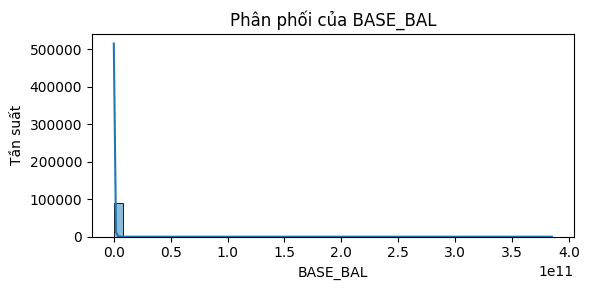

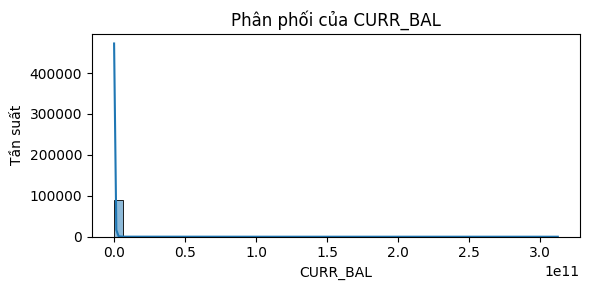

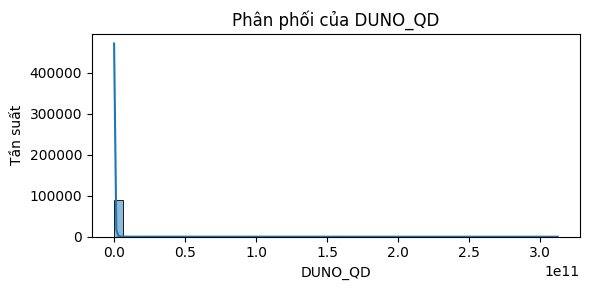

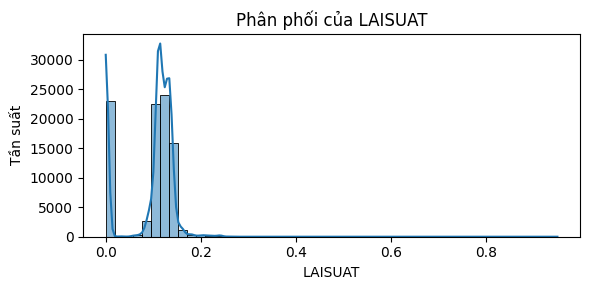

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT']:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')
    plt.tight_layout()
    plt.show()


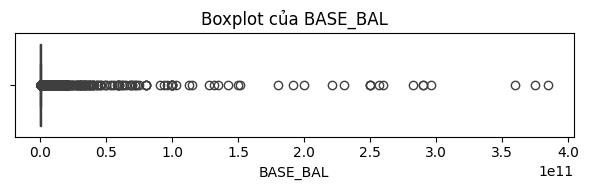

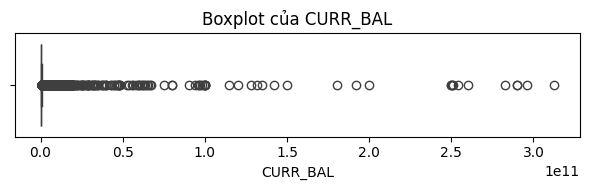

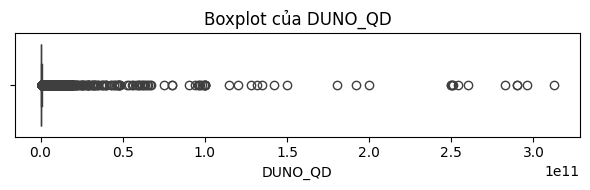

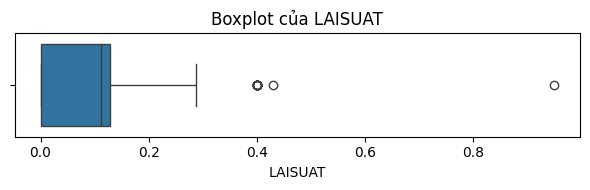

In [ ]:
for col in ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT']:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot của {col}')
    plt.tight_layout()
    plt.show()


In [ ]:
df[['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT']].corr()


,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT
BASE_BAL,1.000000,0.945619,0.945312,0.019868
CURR_BAL,0.945619,1.000000,0.999676,0.019100
DUNO_QD,0.945312,0.999676,1.000000,0.018738
LAISUAT,0.019868,0.019100,0.018738,1.000000


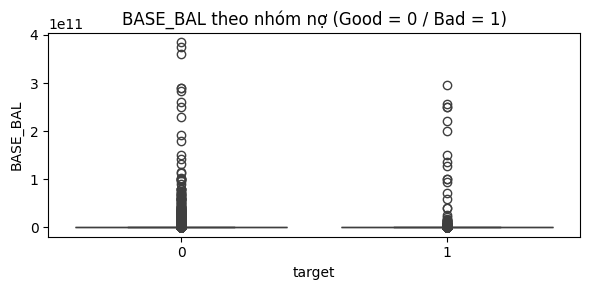

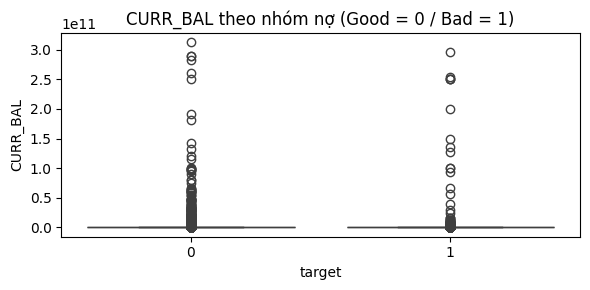

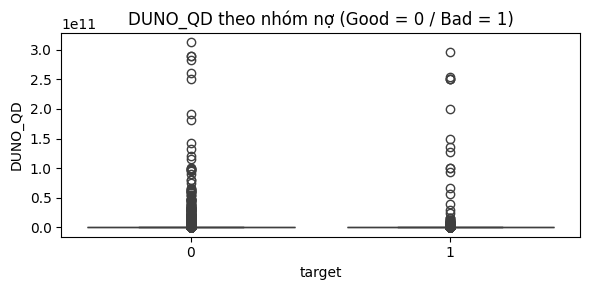

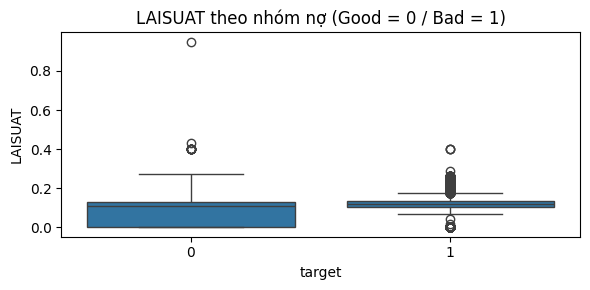

In [ ]:
df['target'] = df['NHOMNOMOI'].apply(lambda x: 1 if x > 1 else 0)

for col in ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT']:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=df, x='target', y=col)
    plt.title(f'{col} theo nhóm nợ (Good = 0 / Bad = 1)')
    plt.tight_layout()
    plt.show()


In [ ]:


df['CURR_BAL_log'] = np.log1p(df['CURR_BAL'])  # log(1 + x)
bins = [0, 5e7, 2e8, 1e9, 1e11]  # có thể điều chỉnh tùy theo phân phối
labels = ['Nhỏ', 'Vừa', 'Lớn', 'Rất lớn']
df['CURR_BAL_group'] = pd.cut(df['CURR_BAL'], bins=bins, labels=labels)


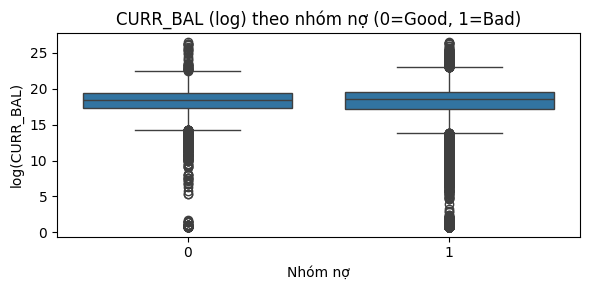

In [ ]:
df['target'] = df['NHOMNOMOI'].apply(lambda x: 0 if x > 1 else 1)  # 1 = Good

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
sns.boxplot(data=df, x='target', y='CURR_BAL_log')
plt.title('CURR_BAL (log) theo nhóm nợ (0=Good, 1=Bad)')
plt.xlabel('Nhóm nợ')
plt.ylabel('log(CURR_BAL)')
plt.tight_layout()
plt.show()


In [ ]:
df['CURR_BAL_group'].value_counts()


,count
CURR_BAL_group,
Nhỏ,31105
Lớn,28429
Vừa,27808
Rất lớn,2981


In [ ]:
df.head()


,PHUONG THUC CHO VAY,LOAIKH,SEX,CURRENCYCD,DESC_TIME,MJACCTTYPDESC,ORGNAME,PARENTORGNAME,MUCDICHVAY,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT,NHOMNOMOI,target,CURR_BAL_log,CURR_BAL_group
0,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN KHANH HOA,KLB - CN KHANH HOA,1900-SX-DV Tu t.dung Gia dinh,787127020.0,851714900.0,851714900.0,0.12,1,1,20.562762,Lớn
1,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - PGD CAI LANG,KLB - CN DA NANG,1811-CV mua Xe may tra gop,333388030.0,142450650.0,142450650.0,0.18,1,1,18.774506,Vừa
2,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,311014800.0,357000690.0,357000690.0,0.18,1,1,19.693248,Lớn
3,CV TL TH LAI DINH KY VND,1,UNKNOWN,VND,Vay trung han,Vay Tieu dung,KLB - PGD DIEN KHANH,KLB - CN KHANH HOA,1830-CV Sua chua Nha de o,35600000.0,35600000.0,35600000.0,0.24,5,0,17.387856,Nhỏ
4,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,430174020.0,88246180.0,88246180.0,0.18,1,1,18.295641,Vừa


Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.66      0.42      2013
           1       0.95      0.81      0.88     16056

    accuracy                           0.80     18069
   macro avg       0.63      0.74      0.65     18069
weighted avg       0.88      0.80      0.83     18069


Confusion Matrix:


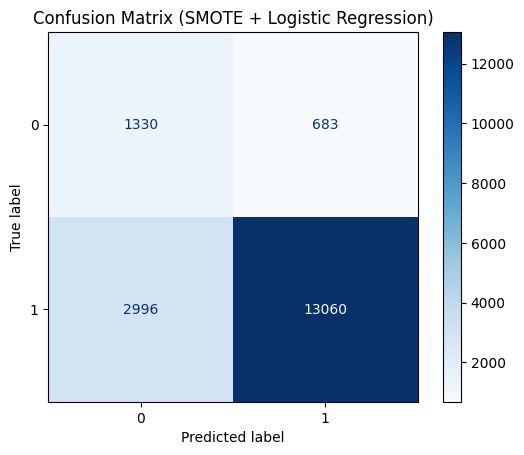

In [ ]:
# 1. Cài đặt thư viện nếu cần
!pip install imbalanced-learn

# 2. Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE

# 3. Chọn cột
selected_columns = [
    'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME',
    'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY',
    'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT', 'NHOMNOMOI'
]
df = df[selected_columns].copy()

# 4. Chuẩn hóa giới tính
sex_mapping = {
    'ONG': 'MR', 'MR': 'MR',
    'BA': 'MRS', 'MRS': 'MRS', 'MS': 'MRS'
}
df['SEX'] = df['SEX'].map(sex_mapping).fillna('UNKNOWN')

# 5. Tạo biến target
df['target'] = df['NHOMNOMOI'].apply(lambda x: 1 if x == 1 else 0)

# 6. Bỏ cột không cần
df_model = df.drop(columns=['NHOMNOMOI'])

# 7. Tách X và y
X = df_model.drop(columns=['target'])
y = df_model['target']

# 8. Xác định categorical và numerical rõ ràng
numerical_cols = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT']
categorical_cols = [col for col in X.columns if col not in numerical_cols]

# 9. Chuyển categorical sang dạng chuỗi (để encode)
for col in categorical_cols:
    X[col] = X[col].astype(str)

# 10. Tiền xử lý
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# 11. Tách train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 12. Xử lý trước khi SMOTE
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 13. SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train)

# 14. Huấn luyện mô hình
model = LogisticRegression(solver='liblinear')
model.fit(X_resampled, y_resampled)

# 15. Dự đoán
y_pred = model.predict(X_test_processed)

# 16. Đánh giá mô hình
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix (SMOTE + Logistic Regression)")
plt.show()


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.32      0.48      2013
           1       0.92      1.00      0.96     16056

    accuracy                           0.92     18069
   macro avg       0.94      0.66      0.72     18069
weighted avg       0.93      0.92      0.91     18069


Confusion Matrix:


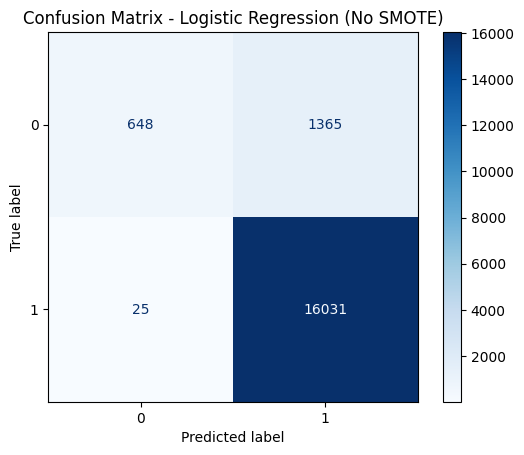

In [ ]:
# 1. Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 2. Chọn các cột cần dùng
selected_columns = [
    'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME',
    'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY',
    'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT', 'NHOMNOMOI'
]
df = df[selected_columns].copy()

# 3. Chuẩn hóa giới tính
sex_mapping = {
    'ONG': 'MR', 'MR': 'MR',
    'BA': 'MRS', 'MRS': 'MRS', 'MS': 'MRS'
}
df['SEX'] = df['SEX'].map(sex_mapping).fillna('UNKNOWN')

# 4. Tạo biến target: 1 = Good (nhóm 1), 0 = Bad
df['target'] = df['NHOMNOMOI'].apply(lambda x: 1 if x == 1 else 0)

# 5. Bỏ cột không cần
df_model = df.drop(columns=['NHOMNOMOI'])

# 6. Tách X và y
X = df_model.drop(columns=['target'])
y = df_model['target']

# 7. Xác định rõ các cột
numerical_cols = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT']
categorical_cols = [col for col in X.columns if col not in numerical_cols]

# 8. Chuyển toàn bộ categorical thành string
for col in categorical_cols:
    X[col] = X[col].astype(str)

# 9. Tiền xử lý
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# 10. Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# 11. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 12. Huấn luyện mô hình
pipeline.fit(X_train, y_train)

# 13. Dự đoán và đánh giá
y_pred = pipeline.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

# 14. Ma trận nhầm lẫn
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (No SMOTE)")
plt.show()


In [ ]:
df.head()

,PHUONG THUC CHO VAY,LOAIKH,SEX,CURRENCYCD,DESC_TIME,MJACCTTYPDESC,ORGNAME,PARENTORGNAME,MUCDICHVAY,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT,NHOMNOMOI,target
0,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN KHANH HOA,KLB - CN KHANH HOA,1900-SX-DV Tu t.dung Gia dinh,787127020.0,851714900.0,851714900.0,0.12,1,1
1,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - PGD CAI LANG,KLB - CN DA NANG,1811-CV mua Xe may tra gop,333388030.0,142450650.0,142450650.0,0.18,1,1
2,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,311014800.0,357000690.0,357000690.0,0.18,1,1
3,CV TL TH LAI DINH KY VND,1,UNKNOWN,VND,Vay trung han,Vay Tieu dung,KLB - PGD DIEN KHANH,KLB - CN KHANH HOA,1830-CV Sua chua Nha de o,35600000.0,35600000.0,35600000.0,0.24,5,0
4,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,430174020.0,88246180.0,88246180.0,0.18,1,1


In [ ]:
df.head()

,PHUONG THUC CHO VAY,LOAIKH,SEX,CURRENCYCD,DESC_TIME,MJACCTTYPDESC,ORGNAME,PARENTORGNAME,MUCDICHVAY,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT,NHOMNOMOI,target
0,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN KHANH HOA,KLB - CN KHANH HOA,1900-SX-DV Tu t.dung Gia dinh,787127020.0,851714900.0,851714900.0,0.12,1,1
1,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - PGD CAI LANG,KLB - CN DA NANG,1811-CV mua Xe may tra gop,333388030.0,142450650.0,142450650.0,0.18,1,1
2,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,311014800.0,357000690.0,357000690.0,0.18,1,1
3,CV TL TH LAI DINH KY VND,1,UNKNOWN,VND,Vay trung han,Vay Tieu dung,KLB - PGD DIEN KHANH,KLB - CN KHANH HOA,1830-CV Sua chua Nha de o,35600000.0,35600000.0,35600000.0,0.24,5,0
4,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,430174020.0,88246180.0,88246180.0,0.18,1,1


In [ ]:
df_model

,PHUONG THUC CHO VAY,LOAIKH,SEX,CURRENCYCD,DESC_TIME,MJACCTTYPDESC,ORGNAME,PARENTORGNAME,MUCDICHVAY,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT,target
0,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN KHANH HOA,KLB - CN KHANH HOA,1900-SX-DV Tu t.dung Gia dinh,7.871270e+08,8.517149e+08,8.517149e+08,0.120,1
1,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - PGD CAI LANG,KLB - CN DA NANG,1811-CV mua Xe may tra gop,3.333880e+08,1.424506e+08,1.424506e+08,0.180,1
2,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,3.110148e+08,3.570007e+08,3.570007e+08,0.180,1
3,CV TL TH LAI DINH KY VND,1,UNKNOWN,VND,Vay trung han,Vay Tieu dung,KLB - PGD DIEN KHANH,KLB - CN KHANH HOA,1830-CV Sua chua Nha de o,3.560000e+07,3.560000e+07,3.560000e+07,0.240,0
4,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,4.301740e+08,8.824618e+07,8.824618e+07,0.180,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90339,CV THAU CHI CBNV KLB VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - PGD SA DEC,KLB - CN DONG THAP,1860-CV CBCNV KLB,1.585500e+06,1.493199e+07,1.493199e+07,0.098,1
90340,CV TL NH LAI DINH KY VND,1,MRS,VND,Vay ngan han,Vay Cong Thuong,KLB - PGD SA DEC,KLB - CN DONG THAP,0710-HD Thuong nghiep,5.000000e+07,8.000000e+07,8.000000e+07,0.129,1
90341,CV TL NH LAI DINH KY VND,1,MRS,VND,Vay ngan han,Vay Cong Thuong,KLB - CN PHU YEN,KLB - CN PHU YEN,1894-Kinh doanh Ca the,1.200000e+09,1.200000e+09,1.200000e+09,0.106,1
90342,CV TL NH LAI DINH KY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - PGD CUKUIN,KLB - CN DAK LAK,1850-CV the chap STK,5.000000e+08,5.000000e+08,5.000000e+08,0.093,1


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.33      0.49      2013
           1       0.92      1.00      0.96     16056

    accuracy                           0.92     18069
   macro avg       0.95      0.66      0.72     18069
weighted avg       0.93      0.92      0.91     18069


Confusion Matrix:


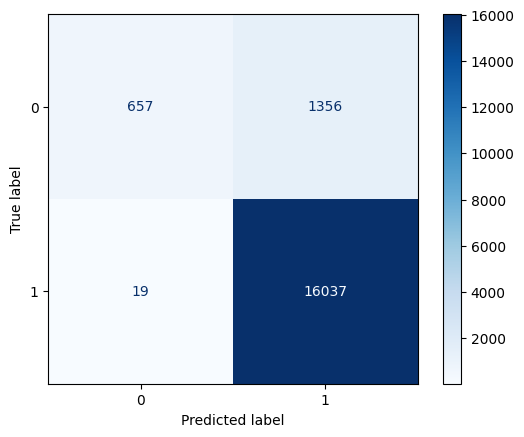

In [ ]:
# 1. Import thư viện
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 2. Bỏ các cột không cần
df_model = df.drop(columns=['CURR_BAL_log', 'CURR_BAL_group', 'NHOMNOMOI'])

# 3. X và y
X = df_model.drop(columns=['target'])
y = df_model['target']

# 4. Undersampling
# Tìm số mẫu tối thiểu giữa 2 lớp
count_class_0, count_class_1 = y.value_counts()

# Tách các nhóm
df_0 = df_model[df_model['target'] == 0].copy() # Add .copy() to avoid SettingWithCopyWarning
df_1 = df_model[df_model['target'] == 1].copy() # Add .copy() to avoid SettingWithCopyWarning

# Undersample lớp nhiều hơn
if count_class_0 > count_class_1:
    df_0_under = df_0.sample(count_class_1, random_state=42)
    df_balanced = pd.concat([df_0_under, df_1])
else:
    df_1_under = df_1.sample(count_class_0, random_state=42)
    df_balanced = pd.concat([df_1_under, df_0])

# Reset lại chỉ số
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Chia lại X, y sau khi cân bằng
X = df_balanced.drop(columns=['target'])
y = df_balanced['target']

# 6. Xác định cột dạng số và phân loại
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Convert all categorical columns to string type to ensure uniformity
# This is the fix for the TypeError
for col in categorical_cols:
    X[col] = X[col].astype(str)

# Re-identify categorical and numerical columns after conversion
# (This step is optional here as we converted to string, but good practice if dtypes might genuinely change)
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


# 7. Tạo pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    # Use handle_unknown='ignore' to handle unseen categories in test set
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# 8. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 9. Huấn luyện
pipeline.fit(X_train, y_train)

# 10. Dự đoán
y_pred = pipeline.predict(X_test)

# 11. Đánh giá
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show() # Add plt.show() to display the plot

In [ ]:
def undersample_dataframe(df, target_col='target', random_state=42):
    """
    Thực hiện undersampling để cân bằng giữa các lớp trong cột target.
    Trả về dataframe đã được undersample.

    Parameters:
        df (pd.DataFrame): Dữ liệu đầu vào
        target_col (str): Tên cột nhãn (label)
        random_state (int): Seed cho reproducibility

    Returns:
        pd.DataFrame: Dữ liệu đã được cân bằng
    """
    # Đếm số mẫu mỗi lớp
    class_counts = df[target_col].value_counts()
    min_class = class_counts.idxmin()
    min_count = class_counts.min()

    # Tách từng lớp
    balanced_parts = []
    for cls in class_counts.index:
        df_cls = df[df[target_col] == cls]
        df_sample = df_cls.sample(min_count, random_state=random_state)
        balanced_parts.append(df_sample)

    # Ghép lại và shuffle
    df_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df_balanced
df_balanced = undersample_dataframe(df, target_col='target')
print(df_balanced['target'].value_counts())  # Kiểm tra cân bằng


target
0    10064
1    10064
Name: count, dtype: int64


In [ ]:
df_balanced.head()

,PHUONG THUC CHO VAY,LOAIKH,SEX,CURRENCYCD,DESC_TIME,MJACCTTYPDESC,ORGNAME,PARENTORGNAME,MUCDICHVAY,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT,target
0,CV THE TIN DUNG VISA_NGUNG SD,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - PGD BA CHIEU,KLB - CN SAI GON,1840-CV master-Visa-JCB card,959200.0,3574120.0,3574120.0,0.000,1
1,CV TL NH LAI DINH KY VND,1,MR,VND,Vay ngan han,Vay Cong Thuong,KLB - PGD HAM TIEN,KLB - CN BINH THUAN,1816-CV Bo sung von luu dong,150000000.0,150000000.0,150000000.0,0.131,1
2,CV THE TIN DUNG VISA_NGUNG SD,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - PGD VUNG TAU,KLB - CN BA RIA - VUNG TAU,1840-CV master-Visa-JCB card,1142900.0,12044722.0,12044722.0,0.000,1
3,"CV TL TH GOC, LAI D.KY VND",1,UNKNOWN,VND,Vay trung han,Vay Tieu dung,KLB - PGD HO PHONG,KLB - CN BAC LIEU,1870-CV TG Sinh hoat Tieu dung,220000000.0,220000000.0,220000000.0,0.120,1
4,CV TL NH LAI DINH KY VND,1,MR,VND,Vay ngan han,Vay Nong Nghiep,KLB - PGD CUKUIN,KLB - CN DAK LAK,0111-Nong nghiep,100000000.0,100000000.0,100000000.0,0.134,1


=== 📘 Logistic Regression (No SMOTE) ===
              precision    recall  f1-score   support

           0       0.96      0.32      0.48      2013
           1       0.92      1.00      0.96     16056

    accuracy                           0.92     18069
   macro avg       0.94      0.66      0.72     18069
weighted avg       0.93      0.92      0.91     18069



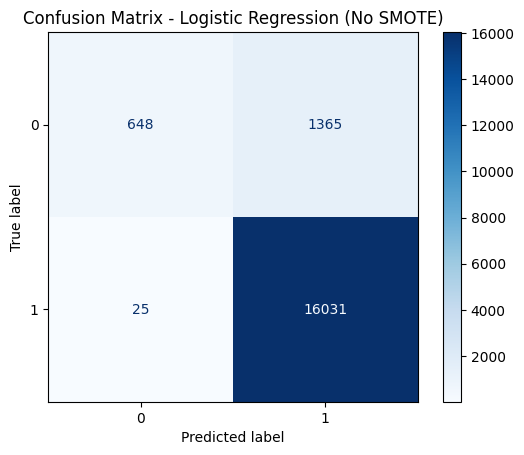

=== 📗 Logistic Regression (With SMOTE) ===
              precision    recall  f1-score   support

           0       0.31      0.66      0.42      2013
           1       0.95      0.81      0.88     16056

    accuracy                           0.80     18069
   macro avg       0.63      0.74      0.65     18069
weighted avg       0.88      0.80      0.83     18069



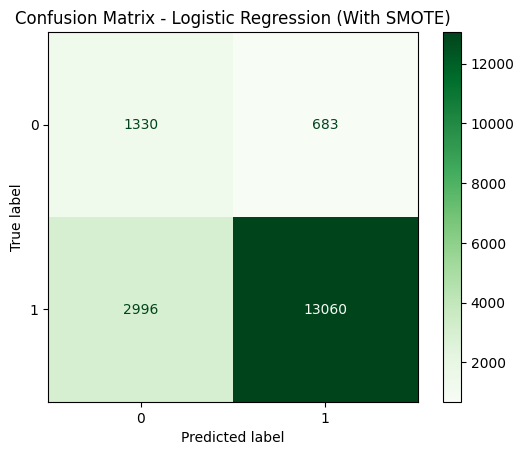

In [ ]:
# 1. Import thư viện
!pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE

# 2. Chuẩn bị dữ liệu
selected_columns = [
    'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME',
    'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY',
    'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT', 'NHOMNOMOI'
]
df = df[selected_columns].copy()

sex_mapping = {'ONG': 'MR', 'MR': 'MR', 'BA': 'MRS', 'MRS': 'MRS', 'MS': 'MRS'}
df['SEX'] = df['SEX'].map(sex_mapping).fillna('UNKNOWN')

df['target'] = df['NHOMNOMOI'].apply(lambda x: 1 if x == 1 else 0)
df_model = df.drop(columns=['NHOMNOMOI'])

X = df_model.drop(columns=['target'])
y = df_model['target']

numerical_cols = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT']
categorical_cols = [col for col in X.columns if col not in numerical_cols]
for col in categorical_cols:
    X[col] = X[col].astype(str)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Mô hình KHÔNG dùng SMOTE
pipeline_no_smote = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])
pipeline_no_smote.fit(X_train, y_train)
y_pred_no_smote = pipeline_no_smote.predict(X_test)

print("=== 📘 Logistic Regression (No SMOTE) ===")
print(classification_report(y_test, y_pred_no_smote))
cm1 = confusion_matrix(y_test, y_pred_no_smote)
ConfusionMatrixDisplay(cm1).plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (No SMOTE)")
plt.show()

# 5. Mô hình dùng SMOTE
# Tiền xử lý trước khi oversampling
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_transformed, y_train)

model_smote = LogisticRegression(solver='liblinear')
model_smote.fit(X_resampled, y_resampled)
y_pred_smote = model_smote.predict(X_test_transformed)

print("=== 📗 Logistic Regression (With SMOTE) ===")
print(classification_report(y_test, y_pred_smote))
cm2 = confusion_matrix(y_test, y_pred_smote)
ConfusionMatrixDisplay(cm2).plot(cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression (With SMOTE)")
plt.show()


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:58:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


=== 🌲 Random Forest (With SMOTE) ===
              precision    recall  f1-score   support

           0       0.48      0.52      0.50      2013
           1       0.94      0.93      0.93     16056

    accuracy                           0.88     18069
   macro avg       0.71      0.73      0.72     18069
weighted avg       0.89      0.88      0.89     18069



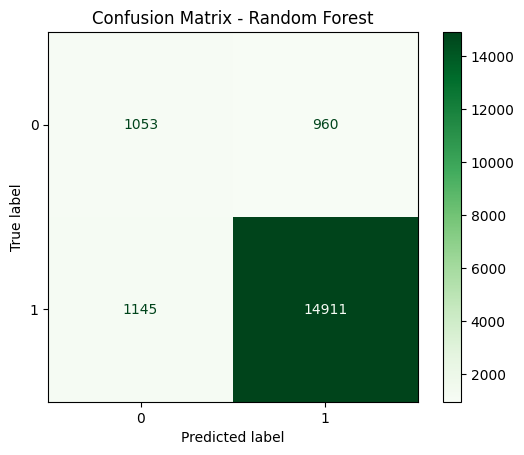

=== ⚡ XGBoost (With SMOTE) ===
              precision    recall  f1-score   support

           0       0.49      0.57      0.53      2013
           1       0.95      0.93      0.94     16056

    accuracy                           0.89     18069
   macro avg       0.72      0.75      0.73     18069
weighted avg       0.90      0.89      0.89     18069



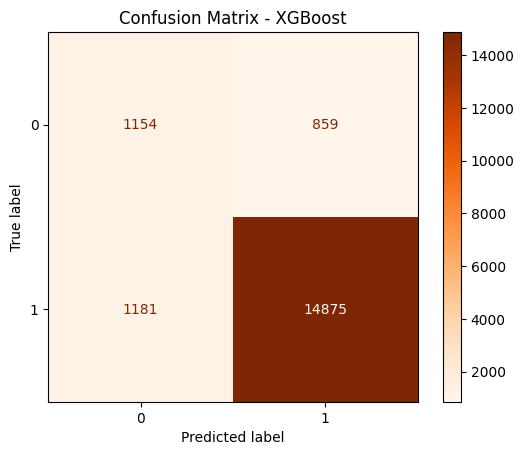

In [ ]:
# Cài thư viện nếu chưa có
!pip install xgboost imbalanced-learn

# Import thư viện
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Huấn luyện Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_resampled, y_resampled)
y_pred_rf = rf_model.predict(X_test_processed)

# 2. Huấn luyện XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_resampled, y_resampled)
y_pred_xgb = xgb_model.predict(X_test_processed)

# 3. Đánh giá Random Forest
print("=== 🌲 Random Forest (With SMOTE) ===")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# 4. Đánh giá XGBoost
print("=== ⚡ XGBoost (With SMOTE) ===")
print(classification_report(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(confusion_matrix=cm_xgb).plot(cmap='Oranges')
plt.title("Confusion Matrix - XGBoost")
plt.show()


=== 🎯 F1-score theo các ngưỡng threshold ===
Threshold: 0.10 | F1-score (Bad=0): 0.4717
Threshold: 0.15 | F1-score (Bad=0): 0.5120
Threshold: 0.20 | F1-score (Bad=0): 0.5315
Threshold: 0.25 | F1-score (Bad=0): 0.5466
Threshold: 0.30 | F1-score (Bad=0): 0.5663
Threshold: 0.35 | F1-score (Bad=0): 0.5672
Threshold: 0.40 | F1-score (Bad=0): 0.5616
Threshold: 0.45 | F1-score (Bad=0): 0.5515
Threshold: 0.50 | F1-score (Bad=0): 0.5308
Threshold: 0.55 | F1-score (Bad=0): 0.5044
Threshold: 0.60 | F1-score (Bad=0): 0.4678
Threshold: 0.65 | F1-score (Bad=0): 0.4363
Threshold: 0.70 | F1-score (Bad=0): 0.3955
Threshold: 0.75 | F1-score (Bad=0): 0.3597
Threshold: 0.80 | F1-score (Bad=0): 0.3138
Threshold: 0.85 | F1-score (Bad=0): 0.2711
Threshold: 0.90 | F1-score (Bad=0): 0.2397


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


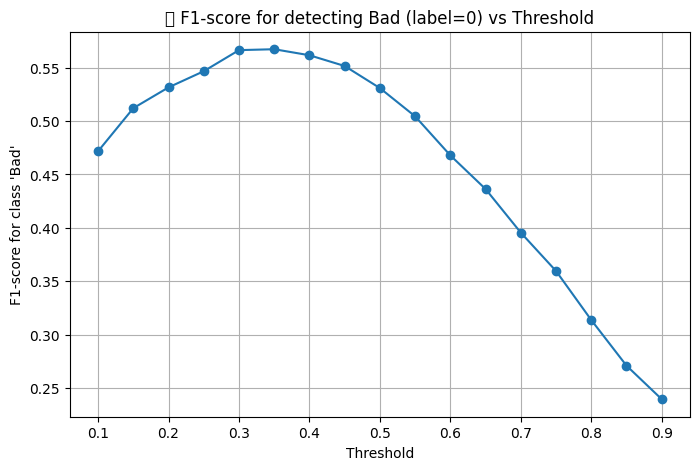


✅ Ngưỡng tốt nhất: 0.35 — F1-score (Bad=0): 0.5672

=== ⚡ XGBoost (Threshold adjusted) ===
              precision    recall  f1-score   support

           0       0.70      0.48      0.57      2013
           1       0.94      0.97      0.96     16056

    accuracy                           0.92     18069
   macro avg       0.82      0.73      0.76     18069
weighted avg       0.91      0.92      0.91     18069



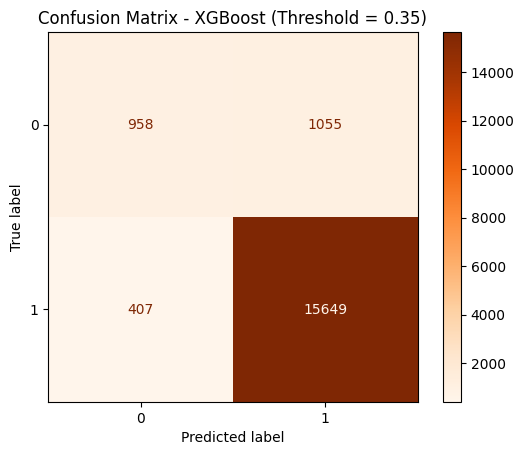

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# 1. Lấy xác suất dự đoán từ mô hình XGBoost
y_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]  # Xác suất thuộc lớp 1 (Good)

# 2. Duyệt qua nhiều ngưỡng để tìm threshold tốt nhất
thresholds = np.arange(0.1, 0.91, 0.05)
f1_scores = []

print("=== 🎯 F1-score theo các ngưỡng threshold ===")
for threshold in thresholds:
    y_pred_threshold = (y_proba_xgb >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_threshold, pos_label=0)  # Tập trung đánh giá lớp 'Bad'
    f1_scores.append(f1)
    print(f"Threshold: {threshold:.2f} | F1-score (Bad=0): {f1:.4f}")

# 3. Vẽ biểu đồ f1-score theo threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o')
plt.xlabel("Threshold")
plt.ylabel("F1-score for class 'Bad'")
plt.title("🎯 F1-score for detecting Bad (label=0) vs Threshold")
plt.grid(True)
plt.show()

# 4. Chọn threshold tối ưu và đánh giá lại
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"\n✅ Ngưỡng tốt nhất: {best_threshold:.2f} — F1-score (Bad=0): {max(f1_scores):.4f}")

# 5. Dự đoán lại với threshold tối ưu
y_pred_optimal = (y_proba_xgb >= best_threshold).astype(int)

print("\n=== ⚡ XGBoost (Threshold adjusted) ===")
print(classification_report(y_test, y_pred_optimal))
cm = confusion_matrix(y_test, y_pred_optimal)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Oranges')
plt.title(f"Confusion Matrix - XGBoost (Threshold = {best_threshold:.2f})")
plt.show()
